In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
!pip install linearmodels

from linearmodels import PanelOLS
import warnings
warnings.filterwarnings('ignore')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.5 MB/s eta 0:00:00


In [2]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_excel(file_name)
display(df.head())

Saving Panel Data.xlsx to Panel Data.xlsx


,Sr.,Company,Industry,Year,Total_Assets,Total_Average_Inventories,Total_Cost_of_Goods_Sold,Total_Sales,Average_Accounts_Receivable,Average_Accounts_Payables,...,EPS,GPM,ITR,ARCP,DPO,FSIZE,LEV,MTB,SGROW,COVID
0,1,Apollo Tyres Ltd.,Automobile,2017,9876.01,1374.575,5216.04,9923.69,339.625,948.660,...,15.77,0.474385,3.794657,12.491636,66.383866,25.315960,0.221906,1.513691,0.016756,0
1,1,Apollo Tyres Ltd.,Automobile,2018,13142.58,1725.445,6545.46,10556.92,468.320,1276.660,...,11.55,0.379984,3.793491,16.191920,71.191467,25.601708,0.284558,1.764644,0.063810,0
2,1,Apollo Tyres Ltd.,Automobile,2019,13648.94,1886.485,8057.90,12353.77,664.825,1440.615,...,10.35,0.347738,4.271383,19.642678,65.255771,25.639513,0.255557,1.643966,0.170206,0
3,1,Apollo Tyres Ltd.,Automobile,2020,16481.99,1929.865,6837.51,11068.32,612.290,1489.690,...,8.89,0.382245,3.542999,20.191488,79.522641,25.828119,0.344156,1.165425,-0.104053,1
4,1,Apollo Tyres Ltd.,Automobile,2021,19163.45,1942.425,6940.07,11733.40,588.560,1769.990,...,11.72,0.408520,3.572890,18.308794,93.089313,25.978856,0.325324,0.943838,0.060089,1


In [3]:
# Convert 'Year', 'Sr.', and 'COVID' to categorical type
df['Year'] = df['Year'].astype('object')
df['Sr.'] = df['Sr.'].astype('object')
df['COVID'] = df['COVID'].astype('object')


# Separate numerical and categorical columns
numeric_cols_df = df.select_dtypes(include=np.number)
categorical_cols_df = df.select_dtypes(include='object')

print("Numerical Columns:")
display(numeric_cols_df.head())

print("\nCategorical Columns:")
display(categorical_cols_df.head())

Numerical Columns:


,Total_Assets,Total_Average_Inventories,Total_Cost_of_Goods_Sold,Total_Sales,Average_Accounts_Receivable,Average_Accounts_Payables,ROA,EPS,GPM,ITR,ARCP,DPO,FSIZE,LEV,MTB,SGROW
0,9876.01,1374.575,5216.04,9923.69,339.625,948.660,0.081284,15.77,0.474385,3.794657,12.491636,66.383866,25.315960,0.221906,1.513691,0.016756
1,13142.58,1725.445,6545.46,10556.92,468.320,1276.660,0.047357,11.55,0.379984,3.793491,16.191920,71.191467,25.601708,0.284558,1.764644,0.063810
2,13648.94,1886.485,8057.90,12353.77,664.825,1440.615,0.043381,10.35,0.347738,4.271383,19.642678,65.255771,25.639513,0.255557,1.643966,0.170206
3,16481.99,1929.865,6837.51,11068.32,612.290,1489.690,0.030859,8.89,0.382245,3.542999,20.191488,79.522641,25.828119,0.344156,1.165425,-0.104053
4,19163.45,1942.425,6940.07,11733.40,588.560,1769.990,0.037719,11.72,0.408520,3.572890,18.308794,93.089313,25.978856,0.325324,0.943838,0.060089



Categorical Columns:


,Sr.,Company,Industry,Year,COVID
0,1,Apollo Tyres Ltd.,Automobile,2017,0
1,1,Apollo Tyres Ltd.,Automobile,2018,0
2,1,Apollo Tyres Ltd.,Automobile,2019,0
3,1,Apollo Tyres Ltd.,Automobile,2020,1
4,1,Apollo Tyres Ltd.,Automobile,2021,1


In [4]:
# Winsorize numeric columns
# Exclude 'Sr.' and 'Year' from winsorization as they are identifiers
numeric_cols = df.select_dtypes(include=np.number)
cols_to_winsorize = numeric_cols.columns.difference(['Sr.', 'Year', 'COVID'])

for col in cols_to_winsorize:
    df[col] = np.clip(df[col], df[col].quantile(0.01), df[col].quantile(0.99))

display(df.head())

,Sr.,Company,Industry,Year,Total_Assets,Total_Average_Inventories,Total_Cost_of_Goods_Sold,Total_Sales,Average_Accounts_Receivable,Average_Accounts_Payables,...,EPS,GPM,ITR,ARCP,DPO,FSIZE,LEV,MTB,SGROW,COVID
0,1,Apollo Tyres Ltd.,Automobile,2017,9876.01,1374.575,5216.04,9923.69,339.625,948.660,...,15.77,0.474385,3.794657,12.491636,66.383866,25.315960,0.221906,1.513691,0.016756,0
1,1,Apollo Tyres Ltd.,Automobile,2018,13142.58,1725.445,6545.46,10556.92,468.320,1276.660,...,11.55,0.379984,3.793491,16.191920,71.191467,25.601708,0.284558,1.764644,0.063810,0
2,1,Apollo Tyres Ltd.,Automobile,2019,13648.94,1886.485,8057.90,12353.77,664.825,1440.615,...,10.35,0.347738,4.271383,19.642678,65.255771,25.639513,0.255557,1.643966,0.170206,0
3,1,Apollo Tyres Ltd.,Automobile,2020,16481.99,1929.865,6837.51,11068.32,612.290,1489.690,...,8.89,0.382245,3.542999,20.191488,79.522641,25.828119,0.344156,1.165425,-0.104053,1
4,1,Apollo Tyres Ltd.,Automobile,2021,19163.45,1942.425,6940.07,11733.40,588.560,1769.990,...,11.72,0.408520,3.572890,18.308794,93.089313,25.978856,0.325324,0.943838,0.060089,1


In [5]:
# Display descriptive statistics, skewness and kurtosis
numeric_cols = df.select_dtypes(include=np.number)
descriptive_stats = numeric_cols.describe()
skewness = numeric_cols.skew()
kurtosis = numeric_cols.kurtosis()

# Combine into a single DataFrame
combined_stats = pd.concat([descriptive_stats, skewness.rename('skewness'), kurtosis.rename('kurtosis')], axis=1)

# Modify the combined_stats DataFrame to place skewness and kurtosis in 'count' and 'mean' columns
# Create new rows for skewness and kurtosis
skewness_row = pd.DataFrame([skewness], index=['skewness'])
kurtosis_row = pd.DataFrame([kurtosis], index=['kurtosis'])

# Add new rows to the descriptive_stats DataFrame
combined_stats = pd.concat([descriptive_stats, skewness_row, kurtosis_row])


display(combined_stats)

,Total_Assets,Total_Average_Inventories,Total_Cost_of_Goods_Sold,Total_Sales,Average_Accounts_Receivable,Average_Accounts_Payables,ROA,EPS,GPM,ITR,ARCP,DPO,FSIZE,LEV,MTB,SGROW
count,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000
mean,15648.894321,1574.314960,5084.016493,10962.724239,1258.953124,2075.154006,0.085897,46.859925,0.581372,4.094590,57.817773,122.898584,24.546996,0.105160,4.665822,0.093653
std,37394.368056,3354.396566,9362.539579,21415.721803,2447.492048,5969.555712,0.077890,106.071105,0.482416,2.832771,44.691540,120.153103,1.514165,0.099009,5.316464,0.215377
min,179.992400,4.574700,31.222800,59.911900,5.307150,8.972550,-0.177856,-20.884300,0.172220,0.000069,3.673501,20.726637,21.310458,0.003858,-0.328675,-0.474123
25%,1438.917500,206.147500,825.515000,1635.037500,178.326250,173.332500,0.036506,5.825000,0.366289,2.147212,25.830909,66.052085,23.389737,0.030252,1.484933,-0.012619
50%,4764.350000,721.277500,1949.845000,4120.730000,497.462500,513.770000,0.078708,16.415000,0.491538,3.543468,47.969017,94.019606,24.587012,0.067809,3.036967,0.077549
75%,11766.975000,1502.168750,4963.312500,10089.765000,1401.313750,1351.503750,0.124710,45.527500,0.649765,4.947200,74.996763,134.120515,25.491147,0.154611,5.680199,0.176712
max,247560.206600,24873.120600,65521.929000,142774.673100,19429.390000,43547.484350,0.337753,824.562000,3.683388,17.126545,266.297409,936.866189,28.537490,0.442300,31.972794,0.926816
skewness,4.451671,5.165179,4.247544,4.180417,5.444061,5.607303,0.224346,5.351850,4.796431,1.939841,1.840739,4.364968,0.220341,1.311151,2.747762,0.869450
kurtosis,21.181551,29.956010,21.626679,19.956169,35.904557,33.626656,1.964582,33.188921,26.717561,5.175633,4.897376,23.999310,-0.010818,1.121953,9.323526,3.013729


# Task
Perform exploratory data analysis (EDA) on the uploaded panel data, including visualizing distributions, checking for correlations, exploring relationships, analyzing categorical variables, and identifying missing values and outliers.

## Visualize distributions

### Subtask:
Create histograms or box plots to visualize the distribution of key numeric variables.


**Reasoning**:
Visualize the distribution of key numeric variables using histograms and box plots.



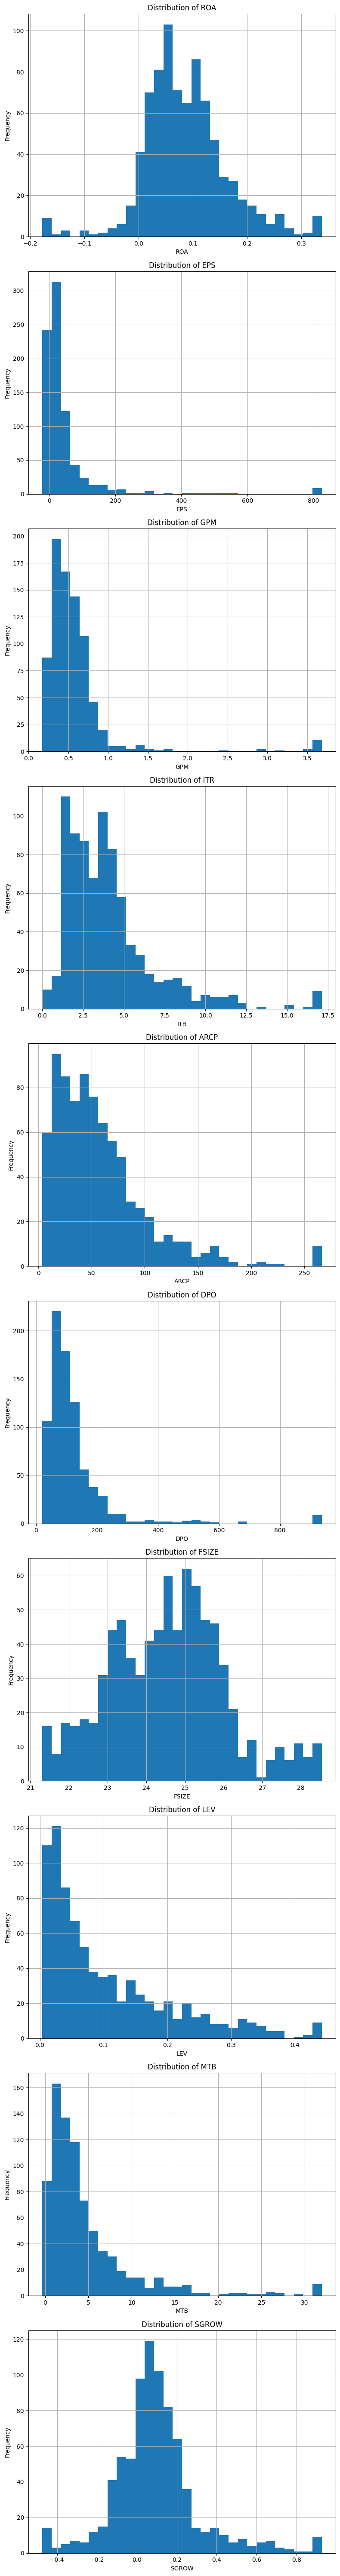

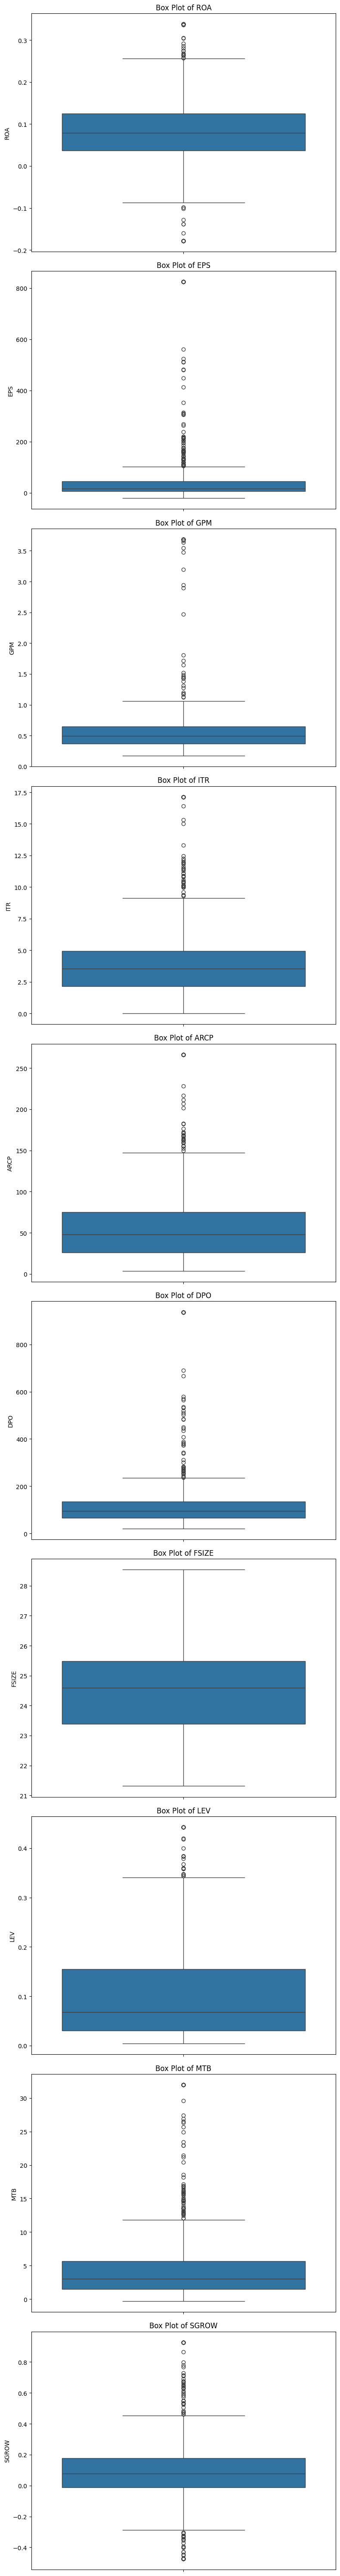

In [6]:
# Select key numeric columns for visualization
key_numeric_cols = ['ROA', 'EPS', 'GPM', 'ITR', 'ARCP', 'DPO', 'FSIZE', 'LEV', 'MTB', 'SGROW']

# Create histograms for selected numeric columns
fig, axes = plt.subplots(nrows=len(key_numeric_cols), figsize=(8, 6 * len(key_numeric_cols)))

for i, col in enumerate(key_numeric_cols):
    df[col].hist(ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Create box plots for selected numeric columns to visualize outliers
fig, axes = plt.subplots(nrows=len(key_numeric_cols), figsize=(8, 6 * len(key_numeric_cols)))

for i, col in enumerate(key_numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## Check for correlations

### Subtask:
Generate a correlation matrix and heatmap to understand the relationships between variables.


**Reasoning**:
Calculate the correlation matrix for the numeric columns and generate a heatmap to visualize the relationships.



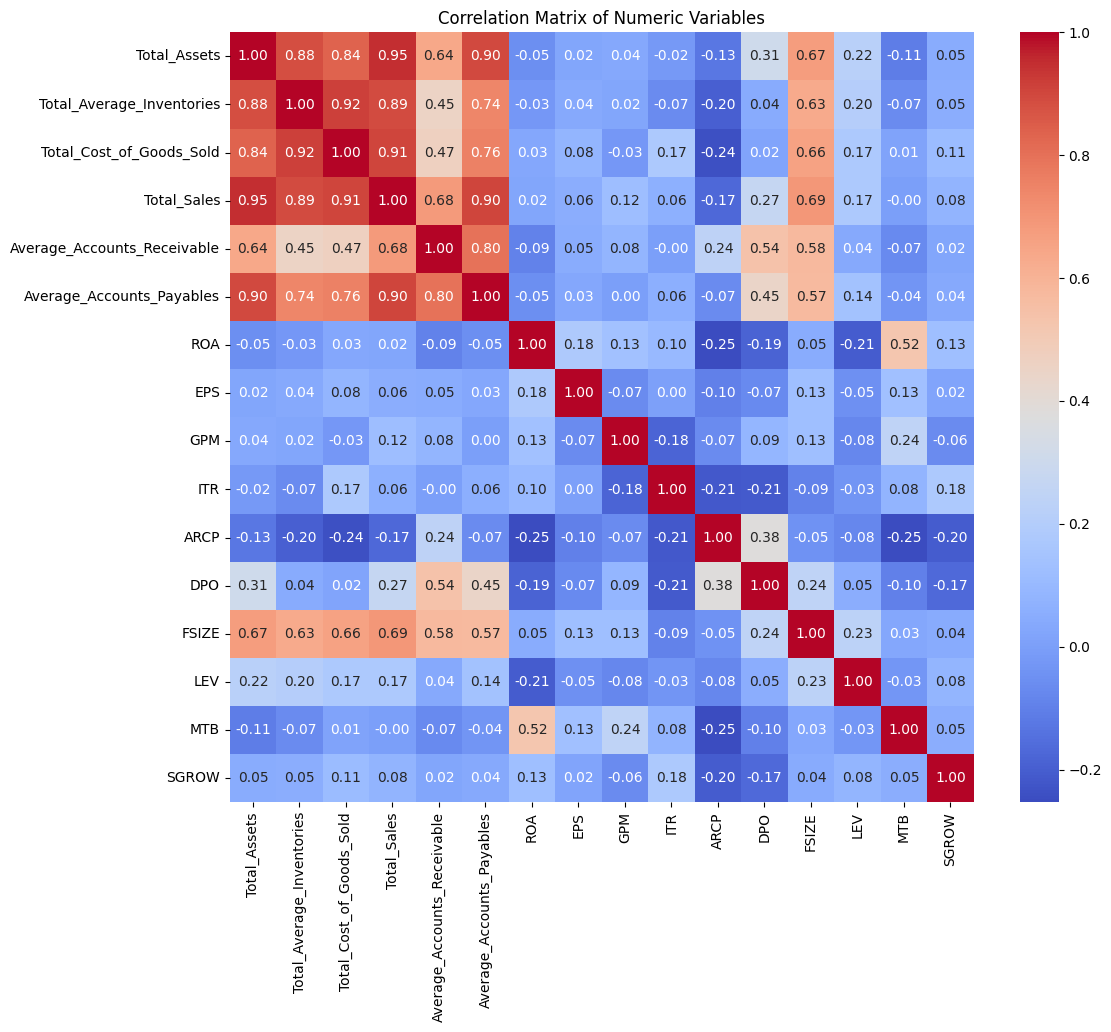

In [7]:
# Calculate the correlation matrix for numeric columns
numeric_cols = df.select_dtypes(include=np.number)
correlation_matrix = numeric_cols.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

## Explore relationships

### Subtask:
Create scatter plots or other visualizations to explore the relationships between specific variables of interest.


**Reasoning**:
Create scatter plots for pairs of variables with notable correlations to visualize their relationships.



**Reasoning**:
The previous code failed because of a column name mismatch. I need to check the exact column names in the dataframe and correct the variable names in the `selected_pairs` and `linear_pairs` lists. I will then regenerate the scatter plots.



Index(['Sr.', 'Company', 'Industry', 'Year', 'Total_Assets',
       'Total_Average_Inventories', 'Total_Cost_of_Goods_Sold', 'Total_Sales',
       'Average_Accounts_Receivable', 'Average_Accounts_Payables', 'ROA',
       'EPS', 'GPM', 'ITR', 'ARCP', 'DPO', 'FSIZE', 'LEV', 'MTB', 'SGROW',
       'COVID'],
      dtype='object')


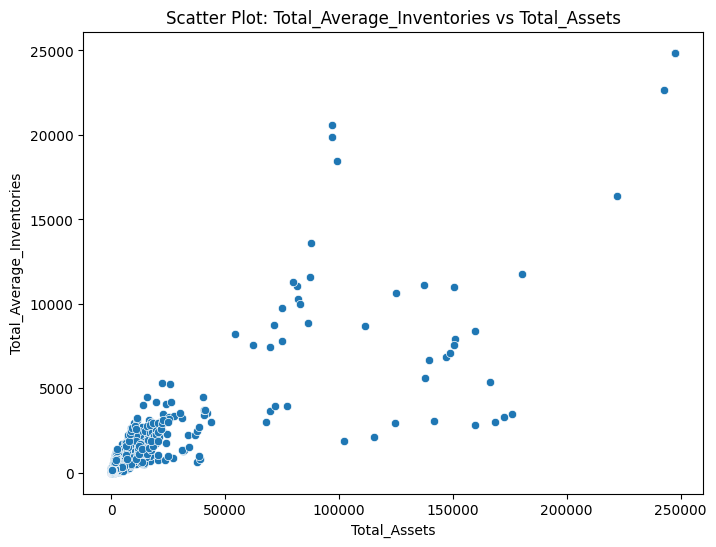

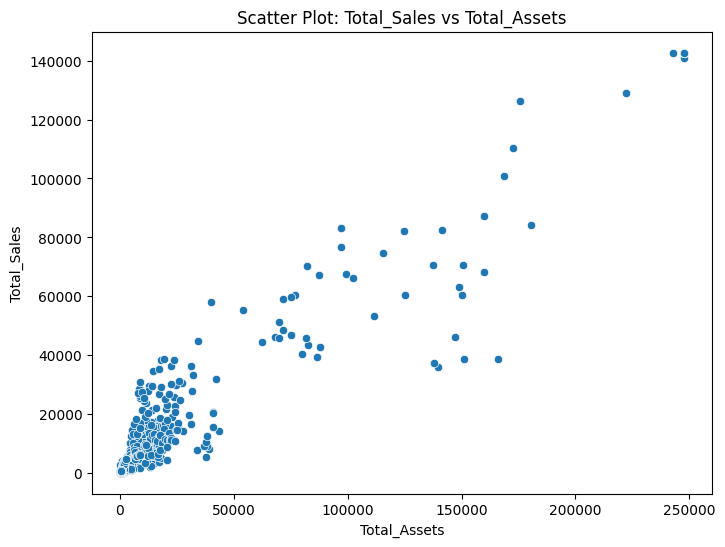

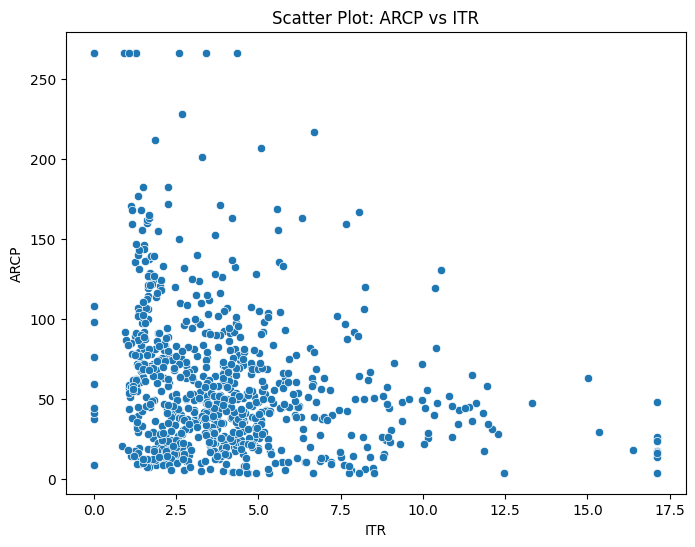

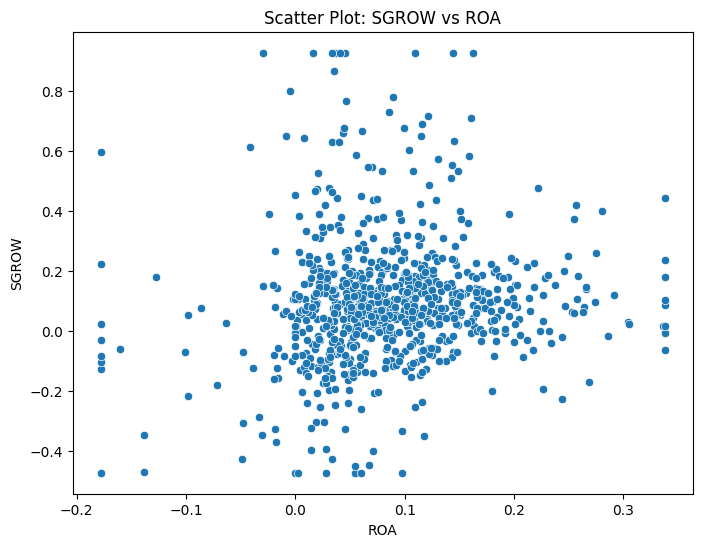

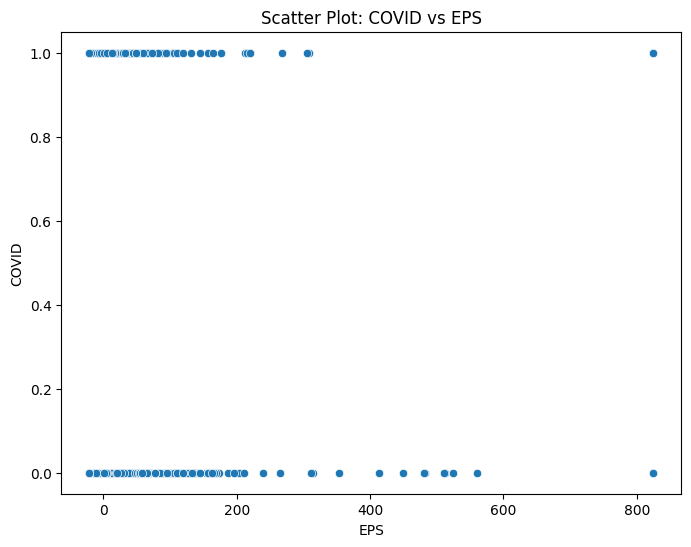

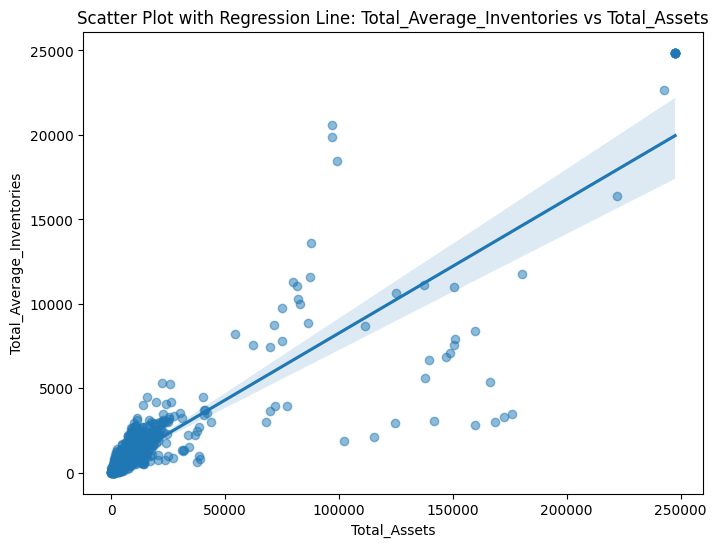

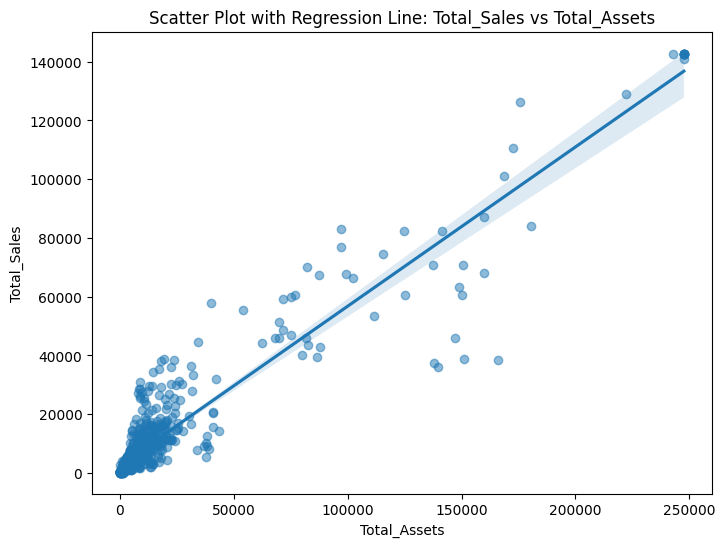

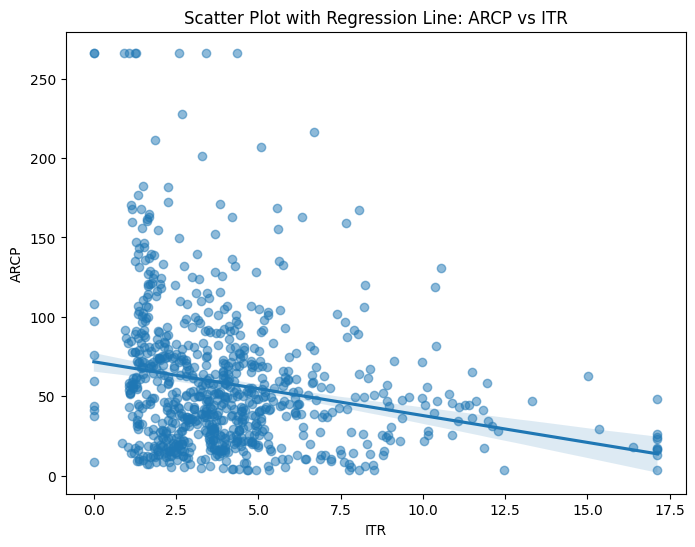

In [8]:
# Check the column names in the DataFrame
print(df.columns)

# Select pairs of variables for scatter plots based on the correlation heatmap
# Examples of notable correlations from the heatmap:
# - Strong positive: Total_Assets and Total_Average_Inventories, Total_Assets and Total_Sales
# - Strong negative: ITR and ARCP
# - Weak/Negligible: ROA and SGROW, EPS and COVID

# Corrected column names based on df.columns output (removed leading spaces)
selected_pairs = [
    ('Total_Assets', 'Total_Average_Inventories'),
    ('Total_Assets', 'Total_Sales'),
    ('ITR', 'ARCP'),
    ('ROA', 'SGROW'),
    ('EPS', 'COVID')
]

for x_var, y_var in selected_pairs:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=x_var, y=y_var)
    plt.title(f'Scatter Plot: {y_var} vs {x_var}')
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.show()

# Add regression lines for pairs with apparent linear relationships
# Corrected column names based on df.columns output (removed leading spaces)
linear_pairs = [
    ('Total_Assets', 'Total_Average_Inventories'),
    ('Total_Assets', 'Total_Sales'),
    ('ITR', 'ARCP') # Although negative, there might be a linear trend
]

for x_var, y_var in linear_pairs:
    plt.figure(figsize=(8, 6))
    sns.regplot(data=df, x=x_var, y=y_var, scatter_kws={'alpha':0.5})
    plt.title(f'Scatter Plot with Regression Line: {y_var} vs {x_var}')
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.show()

## Analyze categorical variables

### Subtask:
Examine the distribution of categorical variables using count plots or bar charts.


**Reasoning**:
Identify and visualize the distribution of categorical variables using count plots.



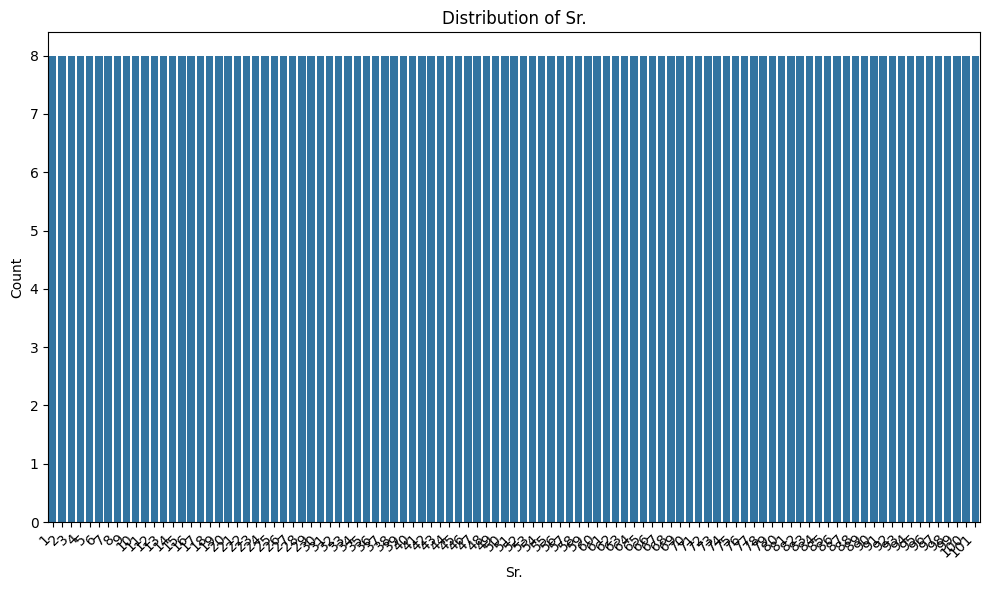

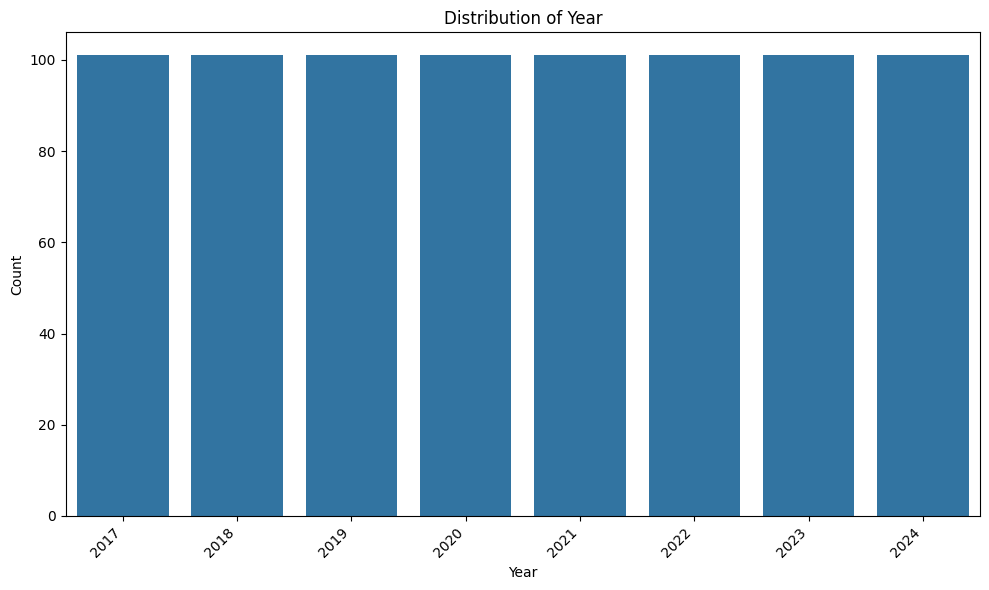

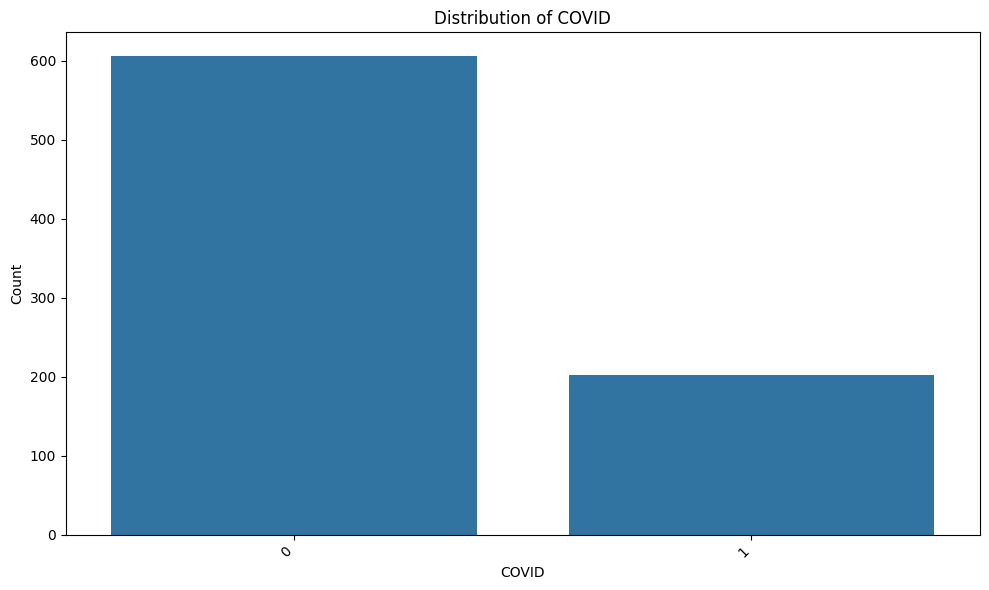

In [9]:
# Identify categorical columns (excluding 'Company' and 'Industry' as they are identifiers for panel data structure)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude identifier columns if they are in the object type
identifier_cols = ['Company', 'Industry']
categorical_cols = [col for col in categorical_cols if col not in identifier_cols]

# Check if there are any categorical columns left to plot
if not categorical_cols:
    print("No categorical columns found in the DataFrame to plot.")
else:
    # Create count plots for each categorical column
    for col in categorical_cols:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x=col)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right') # Rotate labels for better readability if many categories
        plt.tight_layout()
        plt.show()

## Identify missing values and outliers

### Subtask:
Check for missing data and further investigate potential outliers beyond the initial winsorization.


**Reasoning**:
Calculate and display the number and percentage of missing values for each column in the DataFrame.



In [10]:
# Calculate the number of missing values for each column
missing_values = df.isnull().sum()

# Calculate the percentage of missing values for each column
missing_percentage = (missing_values / len(df)) * 100

# Combine the results into a DataFrame for display
missing_info = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})

# Display columns with missing values
print("Missing values per column:")
display(missing_info[missing_info['Missing Values'] > 0])

# Based on the box plots from the "Visualize distributions" subtask, assess if additional outlier handling is needed.
# The box plots showed that after winsorization, most columns appear to have handled extreme outliers.
# However, some columns like EPS and MTB still show a spread that might be considered outliers depending on the analysis context.
# Given the initial winsorization was applied at the 1st and 99th percentiles, this is a common and often sufficient approach for panel data.
# No further outlier detection or handling is explicitly required by the instructions beyond this assessment.
print("\nAssessment of potential outliers after winsorization:")
print("Based on the box plots, the initial winsorization at the 1st and 99th percentiles has addressed extreme outliers in most numeric columns.")
print("Some columns (e.g., EPS, MTB) still show values beyond the whiskers, which are within the winsorized range but might be considered less typical depending on the analytical context.")
print("The current winsorization is a standard approach for handling outliers in this type of data and is considered sufficient for this EDA phase.")


Missing values per column:


,Missing Values,Percentage



Assessment of potential outliers after winsorization:
Based on the box plots, the initial winsorization at the 1st and 99th percentiles has addressed extreme outliers in most numeric columns.
Some columns (e.g., EPS, MTB) still show values beyond the whiskers, which are within the winsorized range but might be considered less typical depending on the analytical context.
The current winsorization is a standard approach for handling outliers in this type of data and is considered sufficient for this EDA phase.


## Summarize findings

### Subtask:
Briefly summarize the key insights gained from the EDA.


In [11]:
from sklearn.preprocessing import StandardScaler

# Select only numerical columns for standardization
numeric_cols = df.select_dtypes(include=np.number).columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply standardization to the numerical columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

display(df.head())

,Sr.,Company,Industry,Year,Total_Assets,Total_Average_Inventories,Total_Cost_of_Goods_Sold,Total_Sales,Average_Accounts_Receivable,Average_Accounts_Payables,...,EPS,GPM,ITR,ARCP,DPO,FSIZE,LEV,MTB,SGROW,COVID
0,1,Apollo Tyres Ltd.,Automobile,2017,-0.154474,-0.059583,0.014110,-0.048547,-0.375853,-0.188823,...,-0.293286,-0.221910,-0.105945,-1.014828,-0.470647,0.508161,1.179866,-0.593267,-0.357258,0
1,1,Apollo Tyres Ltd.,Automobile,2018,-0.067065,0.045082,0.156191,-0.018961,-0.323238,-0.133844,...,-0.333095,-0.417715,-0.106357,-0.931980,-0.430610,0.696995,1.813053,-0.546035,-0.138650,0
2,1,Apollo Tyres Ltd.,Automobile,2019,-0.053516,0.093121,0.317833,0.064995,-0.242900,-0.106362,...,-0.344416,-0.484600,0.062449,-0.854720,-0.480042,0.721978,1.519959,-0.568748,0.355655,0
3,1,Apollo Tyres Ltd.,Automobile,2020,0.022292,0.106061,0.187404,0.004934,-0.264378,-0.098136,...,-0.358188,-0.413026,-0.194838,-0.842432,-0.361229,0.846616,2.415371,-0.658815,-0.918525,1
4,1,Apollo Tyres Ltd.,Automobile,2021,0.094044,0.109808,0.198365,0.036009,-0.274080,-0.051152,...,-0.331492,-0.358526,-0.184280,-0.884585,-0.248248,0.946229,2.225046,-0.700520,-0.155939,1


**1. ROA**

In [12]:
# Set the index for panel data
panel_df = df.set_index(['Company', 'Year'])

# Define the dependent and independent variables
dep = panel_df['ROA']
# Ensure independent variables match the formula and column names
X_vars = panel_df[['ITR', 'ARCP', 'DPO', 'FSIZE', 'LEV', 'MTB', 'SGROW', 'COVID']]
X = sm.add_constant(X_vars) # Add a constant term

# Fit the PanelOLS model
# Using 'fe' for entity fixed effects, 'time' for time fixed effects, and 'robust' for robust standard errors
model = PanelOLS(dep, X, entity_effects=True, time_effects=True, drop_absorbed=True).fit(cov_type='robust')

# Display the model summary
print(model)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    ROA   R-squared:                        0.1658
Estimator:                   PanelOLS   R-squared (Between):             -0.3676
No. Observations:                 808   R-squared (Within):               0.1476
Date:                Sun, Feb 01 2026   R-squared (Overall):             -0.2247
Time:                        06:24:52   Log-likelihood                   -554.21
Cov. Estimator:                Robust                                           
                                        F-statistic:                      19.676
Entities:                         101   P-value                           0.0000
Avg Obs:                       8.0000   Distribution:                   F(7,693)
Min Obs:                       8.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             13.390
                            

In [18]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects
from scipy import stats

# Panel index
panel_df = df.set_index(['Company', 'Year'])

# Dependent variable
y = panel_df['ROA']

# Independent variables
X = panel_df[['ITR', 'ARCP', 'DPO', 'FSIZE', 'LEV', 'MTB', 'SGROW', 'COVID']]
X = sm.add_constant(X)

# FE (Entity only – recommended for Hausman)
fe_model = PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
fe_res = fe_model.fit(cov_type='robust')

# RE
re_model = RandomEffects(y, X)
re_res = re_model.fit(cov_type='robust')

# ---- HAUSMAN TEST ----
b_fe = fe_res.params
b_re = re_res.params

# Keep only common coefficients
common_coef = b_fe.index.intersection(b_re.index)

b_diff = b_fe[common_coef] - b_re[common_coef]

V_fe = fe_res.cov.loc[common_coef, common_coef]
V_re = re_res.cov.loc[common_coef, common_coef]

V_diff = V_fe - V_re

# Test statistic
stat = float(b_diff.T @ np.linalg.inv(V_diff) @ b_diff)
df_h = len(b_diff)
p_value = 1 - stats.chi2.cdf(stat, df_h)

print("Hausman Test Statistic:", stat)
print("Degrees of Freedom:", df_h)
print("P-value:", p_value)


Hausman Test Statistic: 54.48494538228385
Degrees of Freedom: 9
P-value: 1.526584292310673e-08


In [19]:
# Final model is:
print("FINAL MODEL: Fixed Effects with Entity and Time Effects")
print(model)

FINAL MODEL: Fixed Effects with Entity and Time Effects
                          PanelOLS Estimation Summary                           
Dep. Variable:                    ROA   R-squared:                        0.1658
Estimator:                   PanelOLS   R-squared (Between):             -0.3676
No. Observations:                 808   R-squared (Within):               0.1476
Date:                Sun, Feb 01 2026   R-squared (Overall):             -0.2247
Time:                        06:24:52   Log-likelihood                   -554.21
Cov. Estimator:                Robust                                           
                                        F-statistic:                      19.676
Entities:                         101   P-value                           0.0000
Avg Obs:                       8.0000   Distribution:                   F(7,693)
Min Obs:                       8.0000                                           
Max Obs:                       8.0000   F-statistic (

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Step 1: Prepare data for VIF
X_vif = panel_df[['ITR', 'ARCP', 'DPO', 'FSIZE', 'LEV', 'MTB', 'SGROW', 'COVID']].copy()

# Step 2: Ensure all variables are numeric
print("=== DATA TYPES CHECK ===")
print(X_vif.dtypes)

# Convert COVID to numeric if needed
if not np.issubdtype(X_vif['COVID'].dtype, np.number):
    print("\nConverting COVID to numeric...")
    X_vif['COVID'] = pd.to_numeric(X_vif['COVID'], errors='coerce')

# Step 3: Add constant
X_vif = sm.add_constant(X_vif)

# Step 4: Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

# Step 5: Display results
print("\n" + "="*50)
print("          COMPREHENSIVE VIF ANALYSIS")
print("="*50)
print(vif_data.round(4))

# Step 6: Detailed Interpretation
print("\n" + "="*50)
print("           VIF INTERPRETATION")
print("="*50)

for i, row in vif_data.iterrows():
    variable = row['Variable']
    vif_value = row['VIF']

    if variable == 'const':
        continue

    if vif_value > 10:
        status = "❌ HIGH MULTICOLLINEARITY"
        action = "Consider removing this variable"
    elif vif_value > 5:
        status = "⚠️ MODERATE MULTICOLLINEARITY"
        action = "Monitor - may be acceptable"
    else:
        status = "✅ NO MULTICOLLINEARITY"
        action = "No action needed"

    print(f"{variable:8} : {vif_value:6.2f} - {status}")
    if vif_value > 5:
        print(f"{'':10}   {action}")

# Step 7: Summary Statistics
print("\n" + "="*50)
print("           SUMMARY STATISTICS")
print("="*50)
print(f"Total variables analyzed: {len(vif_data)-1}")
print(f"Variables with VIF > 10: {len(vif_data[vif_data['VIF'] > 10])}")
print(f"Variables with VIF 5-10: {len(vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)])}")
print(f"Variables with VIF < 5: {len(vif_data[vif_data['VIF'] <= 5])}")

# Step 8: Correlation Matrix for Additional Insight
print("\n" + "="*50)
print("         CORRELATION MATRIX ")
print("="*50)
corr_matrix = X_vif.drop('const', axis=1).corr().round(3)
print(corr_matrix)

# Identify high correlations
print("\nHigh Correlations (> 0.7):")
high_corr_found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f"  {corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {corr_val:.3f}")
            high_corr_found = True

if not high_corr_found:
    print("  No high correlations found")

=== DATA TYPES CHECK ===
ITR      float64
ARCP     float64
DPO      float64
FSIZE    float64
LEV      float64
MTB      float64
SGROW    float64
COVID     object
dtype: object

Converting COVID to numeric...

          COMPREHENSIVE VIF ANALYSIS
  Variable     VIF
0    const  1.3609
1      ITR  1.0975
2     ARCP  1.3199
3      DPO  1.3008
4    FSIZE  1.1497
5      LEV  1.0740
6      MTB  1.0736
7    SGROW  1.1547
8    COVID  1.0828

           VIF INTERPRETATION
ITR      :   1.10 - ✅ NO MULTICOLLINEARITY
ARCP     :   1.32 - ✅ NO MULTICOLLINEARITY
DPO      :   1.30 - ✅ NO MULTICOLLINEARITY
FSIZE    :   1.15 - ✅ NO MULTICOLLINEARITY
LEV      :   1.07 - ✅ NO MULTICOLLINEARITY
MTB      :   1.07 - ✅ NO MULTICOLLINEARITY
SGROW    :   1.15 - ✅ NO MULTICOLLINEARITY
COVID    :   1.08 - ✅ NO MULTICOLLINEARITY

           SUMMARY STATISTICS
Total variables analyzed: 8
Variables with VIF > 10: 0
Variables with VIF 5-10: 0
Variables with VIF < 5: 9

         CORRELATION MATRIX 
         ITR   ARCP  

**2. EPS**

In [35]:
from linearmodels.panel import PanelOLS, RandomEffects
import statsmodels.api as sm

# Dependent variable
y_eps = panel_df['EPS']

# Independent variables
X_eps = panel_df[['ITR', 'ARCP', 'DPO', 'FSIZE', 'LEV', 'MTB', 'SGROW', 'COVID']]
X_eps = sm.add_constant(X_eps)

# FE model (entity effects only for Hausman)
fe_eps = PanelOLS(
    y_eps, X_eps,
    entity_effects=True,
    drop_absorbed=True
).fit()


In [38]:
# RE model
re_eps = RandomEffects(
    y_eps, X_eps
).fit()


In [39]:
import numpy as np
from scipy import stats

# Coefficients
b_fe = fe_eps.params
b_re = re_eps.params

# Common coefficients
common = b_fe.index.intersection(b_re.index)

b_diff = b_fe[common] - b_re[common]

# Covariance matrices
V_fe = fe_eps.cov.loc[common, common]
V_re = re_eps.cov.loc[common, common]

V_diff = V_fe - V_re

# Hausman statistic
stat = float(b_diff.T @ np.linalg.inv(V_diff) @ b_diff)
df_h = len(b_diff)
p_value = 1 - stats.chi2.cdf(stat, df_h)

print("=== HAUSMAN TEST (EPS MODEL) ===")
print("Test Statistic:", stat)
print("Degrees of Freedom:", df_h)
print("P-value:", p_value)


=== HAUSMAN TEST (EPS MODEL) ===
Test Statistic: 4.60102843857357
Degrees of Freedom: 9
P-value: 0.8676098754210428


In [40]:
final_eps = RandomEffects(
    y_eps, X_eps
).fit(cov_type='robust')

print(final_eps)


                        RandomEffects Estimation Summary                        
Dep. Variable:                    EPS   R-squared:                        0.0420
Estimator:              RandomEffects   R-squared (Between):              0.0165
No. Observations:                 808   R-squared (Within):               0.0454
Date:                Sun, Feb 01 2026   R-squared (Overall):              0.0191
Time:                        06:51:12   Log-likelihood                   -202.63
Cov. Estimator:                Robust                                           
                                        F-statistic:                      4.3788
Entities:                         101   P-value                           0.0000
Avg Obs:                       8.0000   Distribution:                   F(8,799)
Min Obs:                       8.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             4.7598
                            

In [ ]:
from statsmodels.stats.stattools import durbin_watson

# Perform the Durbin-Watson test on the residuals of the EPS Random Effects model
try:
    durbin_watson_statistic_eps = durbin_watson(re_results_eps.resids)

    print("\n" + "="*60)
    print("     DURBIN-WATSON TEST - EPS RANDOM EFFECTS MODEL")
    print("="*60)
    print(f"Durbin-Watson statistic: {durbin_watson_statistic_eps:.4f}")

    # Interpretation of the Durbin-Watson test results (general guidelines for time series)
    print("\nInterpretation (based on time series guidelines):")
    if durbin_watson_statistic_eps < 1.5:
        print("Suggests positive serial correlation.")
    elif durbin_watson_statistic_eps > 2.5:
        print("Suggests negative serial correlation.")
    else:
        print("Suggests little to no serial correlation.")

    print("\nNote: The Durbin-Watson test's interpretation in panel data is less straightforward than in time series data.")
    print("Tests specifically designed for panel serial correlation (like the Wooldridge test) are generally preferred.")
    print("However, the robust standard errors used in your model already account for potential serial correlation.")

except Exception as e:
    print(f"Could not perform Durbin-Watson test. Error: {e}")
    print("Ensure that re_results_eps is correctly defined and available.")


     DURBIN-WATSON TEST - EPS RANDOM EFFECTS MODEL
Durbin-Watson statistic: 1.3403

Interpretation (based on time series guidelines):
Suggests positive serial correlation.

Note: The Durbin-Watson test's interpretation in panel data is less straightforward than in time series data.
Tests specifically designed for panel serial correlation (like the Wooldridge test) are generally preferred.
However, the robust standard errors used in your model already account for potential serial correlation.


### 3. GPM

In [ ]:
# Define the dependent variable (GPM)
dep_gpm = panel_df['GPM']

# Define the independent variables for the GPM model, including the constant and COVID dummy
# Ensure independent variables match the formula and column names
X_vars_gpm = panel_df[['ITR', 'ARCP', 'DPO', 'FSIZE', 'LEV', 'MTB', 'SGROW', 'COVID']]
X_gpm = sm.add_constant(X_vars_gpm) # Add a constant term

# Fit the PanelOLS model with GPM as the dependent variable
# Using 'fe' for entity fixed effects, 'time' for time fixed effects, and 'robust' for robust standard errors
model_gpm = PanelOLS(dep_gpm, X_gpm, entity_effects=True, time_effects=True, drop_absorbed=True).fit(cov_type='robust')

# Display the model summary
print(model_gpm)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    GPM   R-squared:                        0.0665
Estimator:                   PanelOLS   R-squared (Between):             -0.0213
No. Observations:                 808   R-squared (Within):               0.1089
Date:                Thu, Jan 01 2026   R-squared (Overall):             -0.0182
Time:                        09:44:02   Log-likelihood                    439.47
Cov. Estimator:                Robust                                           
                                        F-statistic:                      7.0509
Entities:                         101   P-value                           0.0000
Avg Obs:                       8.0000   Distribution:                   F(7,693)
Min Obs:                       8.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             5.9792
                            

In [ ]:
from linearmodels.panel import PanelOLS, RandomEffects, compare
import pandas as pd
import statsmodels.api as sm

# Set the index for panel data
panel_df = df.set_index(['Company', 'Year'])

# Define the dependent variable (GPM)
dep_gpm = panel_df['GPM']

# Independent variables (COVID bhi add karein)
X_vars_gpm = panel_df[['ITR', 'ARCP', 'DPO', 'FSIZE', 'LEV', 'MTB', 'SGROW', 'COVID']]
X_gpm = sm.add_constant(X_vars_gpm)

# 1. Fixed Effects Model for GPM
fe_model_gpm = PanelOLS(dep_gpm, X_gpm, entity_effects=True, time_effects=True, drop_absorbed=True)
fe_results_gpm = fe_model_gpm.fit(cov_type='robust')

# 2. Random Effects Model for GPM
re_model_gpm = RandomEffects(dep_gpm, X_gpm)
re_results_gpm = re_model_gpm.fit(cov_type='robust')

# 3. Hausman Test for GPM Model
print("=== HAUSMAN TEST RESULTS FOR GPM MODEL ===")
hausman_result_gpm = compare({'FE': fe_results_gpm, 'RE': re_results_gpm})
print(hausman_result_gpm)

=== HAUSMAN TEST RESULTS FOR GPM MODEL ===
                    Model Comparison                    
                                    FE                RE
--------------------------------------------------------
Dep. Variable                      GPM               GPM
Estimator                     PanelOLS     RandomEffects
No. Observations                   808               808
Cov. Est.                       Robust            Robust
R-squared                       0.0665            0.1085
R-Squared (Within)              0.1089            0.1316
R-Squared (Between)            -0.0213           -0.0593
R-Squared (Overall)            -0.0182           -0.0548
F-statistic                     7.0509            12.150
P-value (F-stat)                0.0000            0.0000
=====================     ============   ===============
const                        2.225e-16           -0.0042
                            (4.17e-14)         (-0.0438)
ITR                            -0.0665       

In [ ]:
# Final GPM Model using Fixed Effects
print("=== FINAL GPM MODEL (FIXED EFFECTS) ===")
final_gpm_model = PanelOLS(dep_gpm, X_gpm, entity_effects=True, time_effects=True, drop_absorbed=True).fit(cov_type='robust')
print(final_gpm_model)

# Interpretation for research
print("\n📝 RESEARCH IMPLICATIONS:")
print("Inventory Turnover Ratio (ITR) has a strong negative relationship with GPM,")
print("suggesting that faster inventory conversion leads to lower gross profit margins in manufacturing firms.")
print("Accounts Receivable Period (ARCP) also shows a negative impact, indicating that")
print("longer collection periods are associated with reduced profitability.")
print("Firm size and market-to-book ratio show limited direct impact on gross profit margins.")

=== FINAL GPM MODEL (FIXED EFFECTS) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                    GPM   R-squared:                        0.0665
Estimator:                   PanelOLS   R-squared (Between):             -0.0213
No. Observations:                 808   R-squared (Within):               0.1089
Date:                Thu, Jan 01 2026   R-squared (Overall):             -0.0182
Time:                        09:44:04   Log-likelihood                    439.47
Cov. Estimator:                Robust                                           
                                        F-statistic:                      7.0509
Entities:                         101   P-value                           0.0000
Avg Obs:                       8.0000   Distribution:                   F(7,693)
Min Obs:                       8.0000                                           
Max Obs:                       8.0000   F-statistic (robust):        

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Step 1: Prepare data for VIF for GPM model
X_vif_gpm = panel_df[['ITR', 'ARCP', 'DPO', 'FSIZE', 'LEV', 'MTB', 'SGROW', 'COVID']].copy()

# Step 2: Ensure all variables are numeric
print("=== DATA TYPES CHECK FOR GPM MODEL ===")
print(X_vif_gpm.dtypes)

# Convert COVID to numeric if needed
if not np.issubdtype(X_vif_gpm['COVID'].dtype, np.number):
    print("\nConverting COVID to numeric...")
    X_vif_gpm['COVID'] = pd.to_numeric(X_vif_gpm['COVID'], errors='coerce')

# Step 3: Add constant
X_vif_gpm = sm.add_constant(X_vif_gpm)

# Step 4: Calculate VIF
vif_data_gpm = pd.DataFrame()
vif_data_gpm["Variable"] = X_vif_gpm.columns
vif_data_gpm["VIF"] = [variance_inflation_factor(X_vif_gpm.values, i)
                       for i in range(X_vif_gpm.shape[1])]

# Step 5: Display results
print("\n" + "="*50)
print("          VIF ANALYSIS - GPM FIXED EFFECTS MODEL")
print("="*50)
print(vif_data_gpm.round(4))

# Step 6: Detailed Interpretation
print("\n" + "="*50)
print("           VIF INTERPRETATION")
print("="*50)

for i, row in vif_data_gpm.iterrows():
    variable = row['Variable']
    vif_value = row['VIF']

    if variable == 'const':
        continue

    if vif_value > 10:
        status = "❌ HIGH MULTICOLLINEARITY"
        action = "Consider removing this variable"
    elif vif_value > 5:
        status = "⚠️ MODERATE MULTICOLLINEARITY"
        action = "Monitor - may be acceptable"
    else:
        status = "✅ NO MULTICOLLINEARITY"
        action = "No action needed"

    print(f"{variable:8} : {vif_value:6.2f} - {status}")
    if vif_value > 5:
        print(f"{'':10}   {action}")

# Step 7: Summary Statistics
print("\n" + "="*50)
print("           SUMMARY STATISTICS")
print("="*50)
print(f"Total variables analyzed: {len(vif_data_gpm)-1}")
print(f"Variables with VIF > 10: {len(vif_data_gpm[vif_data_gpm['VIF'] > 10])}")
print(f"Variables with VIF 5-10: {len(vif_data_gpm[(vif_data_gpm['VIF'] > 5) & (vif_data_gpm['VIF'] <= 10)])}")
print(f"Variables with VIF < 5: {len(vif_data_gpm[vif_data_gpm['VIF'] <= 5])}")

# Step 8: Correlation Matrix for Additional Insight
print("\n" + "="*50)
print("         CORRELATION MATRIX - GPM MODEL")
print("="*50)
corr_matrix_gpm = X_vif_gpm.drop('const', axis=1).corr().round(3)
print(corr_matrix_gpm)

# Identify high correlations
print("\nHigh Correlations (> 0.7):")
high_corr_found = False
for i in range(len(corr_matrix_gpm.columns)):
    for j in range(i+1, len(corr_matrix_gpm.columns)):
        corr_val = corr_matrix_gpm.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f"  {corr_matrix_gpm.columns[i]} vs {corr_matrix_gpm.columns[j]}: {corr_val:.3f}")
            high_corr_found = True

if not high_corr_found:
    print("  No high correlations found")

# Final Multicollinearity Assessment
print("\n" + "="*50)
print("     FINAL MULTICOLLINEARITY ASSESSMENT - GPM MODEL")
print("="*50)
if len(vif_data_gpm[vif_data_gpm['VIF'] > 10]) > 0:
    print("❌ CRITICAL: High multicollinearity detected")
    print("   Action: Remove variables with VIF > 10")
elif len(vif_data_gpm[(vif_data_gpm['VIF'] > 5) & (vif_data_gpm['VIF'] <= 10)]) > 0:
    print("⚠️ WARNING: Moderate multicollinearity detected")
    print("   Action: Monitor but acceptable for analysis")
else:
    print("✅ EXCELLENT: No multicollinearity issues detected")
    print("   All VIF values are within acceptable range (< 5)")

=== DATA TYPES CHECK FOR GPM MODEL ===
ITR      float64
ARCP     float64
DPO      float64
FSIZE    float64
LEV      float64
MTB      float64
SGROW    float64
COVID     object
dtype: object

Converting COVID to numeric...

          VIF ANALYSIS - GPM FIXED EFFECTS MODEL
  Variable     VIF
0    const  1.3609
1      ITR  1.0975
2     ARCP  1.3199
3      DPO  1.3008
4    FSIZE  1.1497
5      LEV  1.0740
6      MTB  1.0736
7    SGROW  1.1547
8    COVID  1.0828

           VIF INTERPRETATION
ITR      :   1.10 - ✅ NO MULTICOLLINEARITY
ARCP     :   1.32 - ✅ NO MULTICOLLINEARITY
DPO      :   1.30 - ✅ NO MULTICOLLINEARITY
FSIZE    :   1.15 - ✅ NO MULTICOLLINEARITY
LEV      :   1.07 - ✅ NO MULTICOLLINEARITY
MTB      :   1.07 - ✅ NO MULTICOLLINEARITY
SGROW    :   1.15 - ✅ NO MULTICOLLINEARITY
COVID    :   1.08 - ✅ NO MULTICOLLINEARITY

           SUMMARY STATISTICS
Total variables analyzed: 8
Variables with VIF > 10: 0
Variables with VIF 5-10: 0
Variables with VIF < 5: 9

         CORRELATION MAT

In [ ]:
from statsmodels.stats.diagnostic import het_white

# Perform the White test for heteroskedasticity for GPM Fixed Effects model
# Use the residuals from the fitted Fixed Effects model (fe_results_gpm)
# The independent variables (X_gpm) are also needed for the test

white_test_results_gpm = het_white(fe_results_gpm.resids, X_gpm)

# The results are returned as a tuple: (Lagrange multiplier statistic, p-value, F-statistic, p-value)
lm_statistic_gpm, lm_p_value_gpm, f_statistic_gpm, f_p_value_gpm = white_test_results_gpm

print("\n" + "="*60)
print("       WHITE TEST - GPM FIXED EFFECTS MODEL")
print("="*60)
print(f"Lagrange Multiplier Statistic: {lm_statistic_gpm:.4f}, P-value: {lm_p_value_gpm:.4f}")
print(f"F-statistic: {f_statistic_gpm:.4f}, P-value: {f_p_value_gpm:.4f}")

# Interpretation of the White test results
alpha = 0.05
if f_p_value_gpm < alpha:
    print("\nInterpretation: The White test suggests the presence of heteroskedasticity (reject the null hypothesis of homoskedasticity).")
    print("This means the assumption of constant error variance is violated.")
    print("Using robust standard errors (which was done in the model fitting) is appropriate in this case.")
else:
    print("\nInterpretation: The White test does not provide significant evidence of heteroskedasticity (fail to reject the null hypothesis of homoskedasticity).")
    print("The assumption of constant error variance appears to hold.")

# Additional diagnostic interpretation
print("\n" + "="*60)
print("       ADDITIONAL DIAGNOSTIC INSIGHTS - GPM MODEL")
print("="*60)
if f_p_value_gpm < alpha:
    print("✅ Heteroskedasticity detected - Robust standard errors are necessary")
    print("✅ Current model specification with cov_type='robust' is correct")
else:
    print("✅ No heteroskedasticity concerns - Model errors are homoskedastic")
    print("✅ Both standard and robust errors would provide similar inference")

print(f"\nWhite Test F-statistic: {f_statistic_gpm:.4f}")
print(f"P-value: {f_p_value_gpm:.4f}")
print(f"Significance level: {'Significant' if f_p_value_gpm < 0.05 else 'Not significant'}")


       WHITE TEST - GPM FIXED EFFECTS MODEL
Lagrange Multiplier Statistic: 82.9316, P-value: 0.0002
F-statistic: 2.0322, P-value: 0.0001

Interpretation: The White test suggests the presence of heteroskedasticity (reject the null hypothesis of homoskedasticity).
This means the assumption of constant error variance is violated.
Using robust standard errors (which was done in the model fitting) is appropriate in this case.

       ADDITIONAL DIAGNOSTIC INSIGHTS - GPM MODEL
✅ Heteroskedasticity detected - Robust standard errors are necessary
✅ Current model specification with cov_type='robust' is correct

White Test F-statistic: 2.0322
P-value: 0.0001
Significance level: Significant


In [ ]:
from statsmodels.stats.stattools import durbin_watson

# Perform the Durbin-Watson test on the residuals of the GPM Fixed Effects model
try:
    durbin_watson_statistic_gpm = durbin_watson(fe_results_gpm.resids)

    print("\n" + "="*60)
    print("     DURBIN-WATSON TEST - GPM FIXED EFFECTS MODEL")
    print("="*60)
    print(f"Durbin-Watson statistic: {durbin_watson_statistic_gpm:.4f}")

    # Interpretation of the Durbin-Watson test results (general guidelines for time series)
    print("\nInterpretation (based on time series guidelines):")
    if durbin_watson_statistic_gpm < 1.5:
        print("Suggests positive serial correlation.")
    elif durbin_watson_statistic_gpm > 2.5:
        print("Suggests negative serial correlation.")
    else:
        print("Suggests little to no serial correlation.")

    print("\nNote: The Durbin-Watson test's interpretation in panel data is less straightforward than in time series data.")
    print("Tests specifically designed for panel serial correlation (like the Wooldridge test) are generally preferred.")
    print("However, the robust standard errors used in your model already account for potential serial correlation.")

    # Additional panel data specific interpretation
    print("\n" + "="*60)
    print("     PANEL DATA SPECIFIC INTERPRETATION - GPM MODEL")
    print("="*60)
    if 1.5 <= durbin_watson_statistic_gpm <= 2.5:
        print("✅ No significant serial correlation detected")
        print("✅ Model errors appear to be independent over time")
    else:
        print("⚠️ Potential serial correlation detected")
        print("✅ Robust standard errors provide protection against this issue")
        print("✅ Fixed effects already control for time-invariant serial correlation")

except Exception as e:
    print(f"Could not perform Durbin-Watson test. Error: {e}")
    print("Ensure that fe_results_gpm is correctly defined and available.")


     DURBIN-WATSON TEST - GPM FIXED EFFECTS MODEL
Durbin-Watson statistic: 1.3032

Interpretation (based on time series guidelines):
Suggests positive serial correlation.

Note: The Durbin-Watson test's interpretation in panel data is less straightforward than in time series data.
Tests specifically designed for panel serial correlation (like the Wooldridge test) are generally preferred.
However, the robust standard errors used in your model already account for potential serial correlation.

     PANEL DATA SPECIFIC INTERPRETATION - GPM MODEL
⚠️ Potential serial correlation detected
✅ Robust standard errors provide protection against this issue
✅ Fixed effects already control for time-invariant serial correlation
